## **Phase 1: Environment & Data Preparation**

### **Environment Setup**

#### **Install and Import Required Packages**

In [3]:
import subprocess
import sys
from pathlib import Path

REQ_FILE = Path("../scripts/requirements.txt")

if not REQ_FILE.exists():
    raise FileNotFoundError(f"{REQ_FILE} not found")

print(f"Using requirements file: {REQ_FILE.resolve()}")

# Step 1: Get currently installed packages
installed = subprocess.check_output(
    [sys.executable, "-m", "pip", "freeze"],
    text=True
)

installed_packages = set()
for line in installed.splitlines():
    pkg = line.split("==")[0].lower()
    installed_packages.add(pkg)

# Step 2: Parse requirements file
required_packages = []
with open(REQ_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith("#"):
            pkg_name = line.split("==")[0].lower()
            required_packages.append((pkg_name, line))

# Step 3: Find missing packages
missing = [full for name, full in required_packages if name not in installed_packages]

# Step 4: Install missing
if missing:
    print("Installing missing packages:")
    for pkg in missing:
        print(f"  - {pkg}")

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", *missing
    ])

    print("Installation complete.")
else:
    print("All required packages are already installed.")

# Step 5: Final verification
print(f"Environment ready on Python {sys.version}")

Using requirements file: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\scripts\requirements.txt
Installing missing packages:
  - numpy==1.26.4
  - seaborn==0.13.2
Installation complete.
Environment ready on Python 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [4]:
from dotenv import load_dotenv
from pathlib import Path
import os

env_path = Path("../scripts/.env")
load_dotenv(env_path, override=True)

required_env = [
    "KAGGLE_USERNAME",
    "KAGGLE_KEY",
    "JAVA_HOME",
    "BASE_DIR",
    "VERTEX_PROJECT_ID",
    "VERTEX_LOCATION"
]

missing_env = [k for k in required_env if not os.getenv(k)]
if missing_env:
    raise EnvironmentError(
        "Missing required environment variables in .env: "
        + ", ".join(missing_env)
    )

print(f"Loaded environment variables from: {env_path.resolve()}")

Loaded environment variables from: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\scripts\.env


In [5]:
import os
import shutil

java_home = os.getenv("JAVA_HOME")
java_bin = shutil.which("java")

if not java_home and not java_bin:
    raise EnvironmentError(
        "Java not found. Set JAVA_HOME or ensure java is available in PATH."
    )

print("JAVA_HOME =", java_home if java_home else "Not explicitly set")
print("java executable =", java_bin if java_bin else "Resolved via JAVA_HOME")

JAVA_HOME = C:\Program Files\Eclipse Adoptium\jdk-25.0.2.10-hotspot
java executable = C:\Program Files\Eclipse Adoptium\jdk-25.0.2.10-hotspot\bin\java.EXE


In [31]:
import re
import json
import time
import torch
import hashlib
import random
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
import google.generativeai as genai
from tqdm import tqdm
from dotenv import load_dotenv
from google.api_core import exceptions
from torch.utils.data import DataLoader
from pyserini.search.lucene import LuceneSearcher
from sentence_transformers import CrossEncoder, InputExample
from transformers import AutoTokenizer, AutoModelForSequenceClassification

#### **Setup File Paths and Folder Structure**

In [7]:
from pathlib import Path
import os

base_dir = os.getenv("BASE_DIR", ".")

# Remove accidental carriage returns/newlines
base_dir = base_dir.replace("\r", "\\r").replace("\n", "\\n")

# Normalize path
base_dir = Path(os.path.normpath(base_dir)).resolve()

# arxiv dataset
arxiv_dir = base_dir / "data" / "arxiv"
arxiv_file = arxiv_dir / "arxiv-metadata-oai-snapshot.json"

# processed data
processed_dir = base_dir / "data" / "processed"
arxiv_chunks = processed_dir / "arxiv_chunks.parquet"
processed_aar_training = processed_dir / "aar_training_data.csv"
processed_pyserini_ingest_dir = processed_dir / "pyserini_ingest"
processed_bm25_index = processed_dir / "bm25_index"
processed_final_evaluation_report = processed_dir / "final_evaluation_report.csv"
processed_aar_dataset = processed_dir / "aar_dataset.jsonl"

# Models
aar_trained_model = base_dir / "models" / "aar_trained_model"

# Other files
evaluation_queries = base_dir / "data" / "evaluation_queries.json"
cache_dir = base_dir / "data" / "vertex_cache"

# results
results_dir = base_dir / "results"

print("BASE_DIR:", base_dir)

BASE_DIR: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution


In [8]:
# Set up subfolders
folders = [
    base_dir / "data" / "arxiv",
    base_dir / "data" / "processed",
    base_dir / "data" / "vertex_cache",
    base_dir / "data" / "processed" / "bm25_index",
    base_dir / "data" / "processed" / "pyserini_ingest",
    base_dir / "models" / "aar_trained_model",
    base_dir / "results"
]

# Verifying and Creating directories as needed
for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Verified: {folder}")

Verified: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\arxiv
Verified: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\processed
Verified: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\vertex_cache
Verified: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\processed\bm25_index
Verified: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\processed\pyserini_ingest
Verified: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\models\aar_trained_model
Verified: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\results


### **Functions for Phase 1**

In [9]:
# function to clean data
def clean_latex_and_brackets(text):
   """
   Cleans LaTeX commands, math blocks, and citation brackets.
   """
   if not isinstance(text, str):
       return ""

   # Remove LaTeX math blocks: $$...$$ and $...$
   text = re.sub(r'\$\$.*?\$\$', '', text, flags=re.DOTALL)
   text = re.sub(r'\$.*?\$', '', text)

   # Remove common LaTeX commands and the curly braces (e.g., \section, \textbf, \cite{...})
   text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)

   # Remove standalone backslashes and remaining LaTeX commands (e.g., \item, \noindent)
   text = re.sub(r'\\[a-zA-Z]+', '', text)

   # Remove citation/reference brackets like [1], [12, 15], or [Smith et al., 2023]
   text = re.sub(r'\[[\d, \s\-a-zA-Z\.]+\]', '', text)

   # Clean up extra whitespace/newlines left behind
   text = re.sub(r'\s+', ' ', text).strip()

   return text

In [10]:
# Function to chunk text using simple sliding window chunker
def chunk_text(text, chunk_size=512, overlap=50):
   cleaned_text = clean_latex_and_brackets(text)
   words = cleaned_text.split()
   chunks = []
   for i in range(0, len(words), chunk_size - overlap):
       chunk = " ".join(words[i:i + chunk_size])
       chunks.append(chunk)
   return chunks

### **Dataset Acquisition & Preprocessing**

#### **Download ArXiv Dataset**

In [49]:
# Retrieve Kaggle credentials
os.environ['KAGGLE_USERNAME'] = os.getenv("KAGGLE_USERNAME")
os.environ['KAGGLE_KEY'] = os.getenv("KAGGLE_KEY")

# Change directory to arxiv
os.chdir(arxiv_dir)

# Download dataset
if arxiv_file.exists():
    print(f"Dataset already available: {arxiv_file}")
else:
    subprocess.run(["kaggle", "datasets", "download", "-d", "Cornell-University/arxiv"])
    
    # Unzip dataset
    with zipfile.ZipFile("arxiv.zip", 'r') as zip_ref:
        zip_ref.extractall(arxiv_dir)
    
    # Remove zip file
    os.remove("arxiv.zip")
    
    print("Download and extraction complete.")

Download and extraction complete.


#### **Clean The Data and Implement Sliding Window Chunking**

In [50]:
# The ArXiv dataset is a massive JSON file. The below code will extract and chunk the text.
processed_chunks = []

with open(arxiv_file, 'r') as f:
   for i, line in enumerate(f):
      #  if i >= 2: break # Process subset for testing
       data = json.loads(line)
       # Focus on 'abstract' as the primary text source for RAG
       full_text = f"Title: {data['title']}\nAbstract: {data['abstract']}"
       chunks = chunk_text(full_text)
       for c in chunks:
           processed_chunks.append({"id": data['id'], "chunk": c})

In [51]:
# Save processed chunks as a Parquet for Phase 2 reranking
chunks_df = pd.DataFrame(processed_chunks)
chunks_df.to_parquet(arxiv_chunks)
print(f"Saved {len(chunks_df)} chunks for RAG pipeline.")

Saved 2989104 chunks for RAG pipeline.


### **Indexing (Stage 1 Retriever)**

#### **Convert Data to Pyserini Format**

In [52]:
# Load your cleaned chunks
df = pd.read_parquet(arxiv_chunks)

# Write chunks to JSONL format
with open(os.path.join(processed_pyserini_ingest_dir, 'docs.jsonl'), 'w') as f:
    for _, row in df.iterrows():
        # Pyserini requires 'id' and 'contents' fields
        pyserini_doc = {
            "id": str(row['id']),
            "contents": row['chunk']
        }
        f.write(json.dumps(pyserini_doc) + '\n')

print(f"Converted {len(df)} chunks to Pyserini-compatible JSONL.")

Converted 2989104 chunks to Pyserini-compatible JSONL.


#### **Build the BM25 Index**

In [53]:
threads = os.getenv("PYSERINI_THREADS", "8")

subprocess.run([
    sys.executable, "-m", "pyserini.index.lucene",
    "--collection", "JsonCollection",
    "--input", str(processed_pyserini_ingest_dir),
    "--index", str(processed_bm25_index),
    "--generator", "DefaultLuceneDocumentGenerator",
    "--threads", str(threads),
    "--storePositions",
    "--storeDocvectors",
    "--storeRaw"
], check=True)

print(f"BM25 Index successfully built at: {processed_bm25_index}")

BM25 Index successfully built at: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\processed\bm25_index


## **Setup Initial Candidate Retrieval using BM25**

In [11]:
# Initialize BM25 Searcher
searcher = LuceneSearcher(str(processed_bm25_index))

In [12]:
# Initial candidate retrieval using BM25. This is the common first stage used by both the baseline and proposed systems.
def Initial_BM25_Candidate_Retrieval(query, k=50):
    # Retrieval (BM25)
    hits = searcher.search(query, k=k)

    # Extract passages for reranking
    passages = [json.loads(searcher.doc(h.docid).raw())['contents'] for h in hits]

    return passages

# Build (query, passage) pairs for cross-encoder style reranking.
def Build_Model_Inputs(query, passages):
    return [[query, passage] for passage in passages]

In [13]:
def Generate_Prompt(top_passages):
    context_str = ""
    for i, p in enumerate(top_passages):
        context_str += f"Source [Doc_{i}]: {p}\n\n"

    prompt = f"""Answer the query using only the sources provided.
You MUST cite the Source ID (e.g. [Doc_0]) immediately after the sentence it supports.
Use only the provided sources when making cited factual claims.
If the sources do not fully support a claim, state the uncertainty clearly.

Sources:
{context_str}
Query: {query}
"""
    return prompt

## **Phase 2: Baseline Implementation**

#### **Vertex API Setup to Access GCP**

In [14]:
# Install Vertex AI SDK
!pip install -q google-cloud-aiplatform

import os
import time
import random
import vertexai
from google.api_core.exceptions import ResourceExhausted, ServiceUnavailable, DeadlineExceeded
from vertexai.generative_models import GenerativeModel

PROJECT_ID = os.getenv("PROJECT_ID", "project-eb7a852b-1394-44fe-b5f")
VERTEX_LOCATION = os.getenv("VERTEX_LOCATION", "global")

vertexai.init(project=PROJECT_ID, location=VERTEX_LOCATION)

# Load Gemini model
llm_generator = GenerativeModel("gemini-2.5-flash")

def generate_content_with_retry(prompt, model=None, retries=8,
                                initial_delay=5.0, max_delay=60.0,
                                temperature=None, sleep_after_success=0.5):
    model = model or llm_generator
    delay = initial_delay
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            if temperature is None:
                response = model.generate_content(prompt)
            else:
                from vertexai.generative_models import GenerationConfig
                response = model.generate_content(
                    prompt,
                    generation_config=GenerationConfig(temperature=temperature)
                )
            time.sleep(sleep_after_success)
            return response
        except (ResourceExhausted, ServiceUnavailable, DeadlineExceeded) as e:
            last_error = e
            if attempt == retries:
                raise
            wait_time = min(max_delay, delay + random.uniform(0, delay * 0.25))
            print(f"Vertex AI transient error on attempt {attempt}/{retries}: {e}. Retrying in {wait_time:.1f}s...")
            time.sleep(wait_time)
            delay *= 2

    raise last_error

C:\Users\Wilson\anaconda3\Lib\site-packages\vertexai\generative_models\_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


#### **Implement Citation Audit Evaluator to Audit the Baseline**

In [44]:
# Standalone evaluator for cited RAG outputs.
class CitationAuditEvaluator:
    def __init__(self, aar_model, margin_threshold=0.035):
        self.evaluator = aar_model
        self.margin_threshold = margin_threshold

    def extract_citations(self, response_text):
        pattern = r"([^.!?]+?)\s*\[([^\]]+)\]"
        matches = re.findall(pattern, response_text)

        extracted = []
        for claim, citation_text in matches:
            claim = claim.strip()
            doc_ids = [c.strip() for c in citation_text.split(",") if c.strip()]
            if claim:
                extracted.append({
                    "claim": claim,
                    "doc_ids": doc_ids
                })
        return extracted

    def verify_claim_against_source(self, claim, source_text):
        prediction = self.evaluator.predict([[claim, source_text]], apply_softmax=True)[0]

        contradict_prob = float(prediction[0])
        attributable_prob = float(prediction[1])
        extrapolatory_prob = float(prediction[2])

        predicted_class = int(np.argmax(prediction))
        sorted_probs = sorted([contradict_prob, attributable_prob, extrapolatory_prob], reverse=True)
        margin = float(sorted_probs[0] - sorted_probs[1])

        status = "PASS" if predicted_class == 1 and margin >= self.margin_threshold else "FAIL"

        return {
            "status": status,
            "confidence": attributable_prob,
            "predicted_class": predicted_class,
            "contradict_prob": contradict_prob,
            "attributable_prob": attributable_prob,
            "extrapolatory_prob": extrapolatory_prob,
            "margin": margin
        }

    def audit_response(self, response_text, retrieved_passages):
        extracted_claims = self.extract_citations(response_text)
        verifications = []

        for item in extracted_claims:
            claim = item["claim"]

            for doc_id_str in item["doc_ids"]:
                doc_match = re.search(r"\d+", doc_id_str)
                if not doc_match:
                    verifications.append({
                        "claim": claim,
                        "doc_id": doc_id_str,
                        "source": None,
                        "status": "FAIL",
                        "confidence": 0.0,
                        "error": "Could not parse document id"
                    })
                    continue

                doc_idx = int(doc_match.group())
                if doc_idx < 0 or doc_idx >= len(retrieved_passages):
                    verifications.append({
                        "claim": claim,
                        "doc_id": doc_id_str,
                        "source": None,
                        "status": "FAIL",
                        "confidence": 0.0,
                        "error": "Document index out of range"
                    })
                    continue

                source_text = retrieved_passages[doc_idx]
                audit = self.verify_claim_against_source(claim, source_text)

                verifications.append({
                    "claim": claim,
                    "doc_id": doc_id_str,
                    "source": source_text,
                    **audit
                })

        return {
            "response_text": response_text,
            "num_extracted_claims": len(extracted_claims),
            "verifications": verifications
        }

    def compute_metrics(self, audit_result):
        verifications = audit_result.get("verifications", [])
        
        if len(verifications) == 0:
            print("No verifications found")
            return {
                "precision": 0.0,
                "recall": 0.0,
                "ags": 0.0,
                "num_verified_claims": 0,
                "num_passed": 0,
                "num_failed": 0
            }

        passed = [v for v in verifications if v["status"] == "PASS"]
        failed = [v for v in verifications if v["status"] == "FAIL"]
        
        precision = len(passed) / len(verifications)
        
        num_extracted_claims = max(audit_result.get("num_extracted_claims", 0), 1)
        recall = len(passed) / num_extracted_claims
        
        grounding_scores = []
        for v in passed:
            source = v.get("source", "")
            wc = len(source.split()) if source else 0
            if wc > 0:
                grounding_scores.append(100 / wc)

        ags = float(np.mean(grounding_scores)) if grounding_scores else 0.0
        
        return {
            "precision": float(precision),
            "recall": float(recall),
            "ags": float(ags),
            "num_verified_claims": int(len(verifications)),
            "num_passed": int(len(passed)),
            "num_failed": int(len(failed))
        }

#### **Implement Baseline**

In [16]:
# Initialize Baseline Relevance Reranker (Standard Cross-Encoder)
# Using ms-marco-MiniLM as it is the standard for semantic relevance
baseline_reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

In [17]:
# Standard relevance-based reranking using an off-the-shelf cross-encoder.
def baseline_relevance_reranking(query, passages, top_n=5):
    model_inputs = Build_Model_Inputs(query, passages)
    scores = baseline_reranker.predict(model_inputs)

    # Sort passages by descending score and return the top_n passages.
    ranked_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    return [passages[i] for i in ranked_indices[:top_n]]

In [58]:
def get_text(response):
    if isinstance(response, str):
        return response
    if hasattr(response, "text"):
        return response.text
    if hasattr(response, "choices"):
        return response.choices[0].message.content
    raise str(response)

In [52]:
# Function to implement the baseline pipeline
def baseline_rag_pipeline(query, k=50, top_n=5, require_citations=False):
    # BM25 candidate retrieval
    candidate_passages = Initial_BM25_Candidate_Retrieval(query, k=k)
    top_passages = baseline_relevance_reranking(query, candidate_passages, top_n=top_n)

    prompt = Generate_Prompt(top_passages)    

    response = generate_content_with_retry_and_cache(prompt, model=llm_generator)
    response_text = get_text(response)

    return {
        "query": query,
        "retrieved_passages": top_passages,
        "generated_answer": response_text
    }

# Function to Audit the baseline pipeline
def audit_baseline_rag_pipeline(query, k=50, top_n=5):
    baseline_out = baseline_rag_pipeline(query, k=k, top_n=top_n, require_citations=True)
    audit_result = citation_auditor.audit_response(
        baseline_out["generated_answer"],
        baseline_out["retrieved_passages"]
    )
    
    metrics = citation_auditor.compute_metrics(audit_result)
    
    return {
        "query": query,
        "generated_answer": baseline_out["generated_answer"],
        "retrieved_passages": baseline_out["retrieved_passages"],
        "audit": audit_result,
        "verifications": audit_result["verifications"],
        **metrics
    }

## **Phase 3: AAR Model Training (NLI Objective)**

### **Synthetic Data Generation**

#### **Required Functions**

In [19]:
# Simple function to fix invalid JSON generated from the generator
def fix_invalid_escapes(text):
    # Replace single backslashes not part of valid escapes
    return re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', text)

# Function to attempt to parse JSON with fallback fixes
def safe_json_loads(text):
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        try:
            fixed = fix_invalid_escapes(text)
            return json.loads(fixed)
        except Exception:
            return None

In [54]:
def generate_aar_triplets_batch(passages, retries=5):
    cleaned_passages = [
        p for p in (clean_latex_and_brackets(p) for p in passages)
        if p and len(p) > 50
    ]

    if not cleaned_passages:
        print("Error: No passages returned after cleaning!")
        return []

    context = "\n\n".join(
        [f"passage_id {i+1}: {p}" for i, p in enumerate(cleaned_passages)]
    )

    prompt = f"""
Below are several context passages.

{context}

For EACH passage generate JSON object with exactly three claims:
1. "attributable": A claim fully and directly supported by the text.
2. "extrapolatory": A claim topically related to the text but NOT supported by it.
3. "contradictory": A claim that directly contradicts information in the text.

Return ONLY valid JSON list:
[
    {{
        "passage_id": "...",
        "passage": "...",
        "attributable": "...",
        "extrapolatory": "...",
        "contradictory": "..."
    }}
]
"""

    for attempt in range(retries):
        try:
            response = generate_content_with_retry(prompt)
            text = get_text(response).replace("```json", "").replace("```", "").strip()

            data = safe_json_loads(text)

            if data is None:
                raise ValueError("Failed to parse JSON after fixes")

            valid_data = []
            for i, d in enumerate(data):
                try:
                    d["passage"] = cleaned_passages[i]
                    valid_data.append(d)
                except Exception as e:
                    print(f"Skipping malformed item {i}: {e}")

            return valid_data

        except exceptions.ResourceExhausted:
            wait = (2 ** attempt) + 5
            print(f"Rate limit hit. Waiting {wait}s")
            time.sleep(wait)

        except Exception as e:
            print("Error:", e)

    return []

In [21]:
# function to normalize the data
def normalize_triplet(row):

    if isinstance(row.get("claims"), list):

        attr = None
        extra = None
        contra = None

        for c in row["claims"]:
            t = c.get("type")
            txt = c.get("claim") or c.get("text")

            if t == "attributable":
                attr = txt
            elif t == "extrapolatory":
                extra = txt
            elif t == "contradictory":
                contra = txt

        return pd.Series({
            "attributable": attr,
            "extrapolatory": extra,
            "contradictory": contra
        })

    else:
        return pd.Series({
            "attributable": row.get("attributable"),
            "extrapolatory": row.get("extrapolatory"),
            "contradictory": row.get("contradictory")
        })

#### **Generate AAR Triplets**

In [22]:
# Define variables for the generation of train data
buffer = []
target_passages = 50
processed = 0
batch_size = 10

# retrieve chunked data
reader = pd.read_parquet(arxiv_chunks, columns=["chunk"])

# process and store the AAR triplet dataset
with open(processed_aar_dataset, "a") as f:
    for passage in tqdm(reader["chunk"], total=target_passages):
        cleaned = clean_latex_and_brackets(passage)

        if not cleaned or len(cleaned) < 50:
          print(f"Error: Passage cleaned came empty. Original passage: {passage} \n cleaned: {cleaned}")
          continue

        buffer.append(cleaned)
        processed += 1

        if len(buffer) == batch_size:
            triplets = generate_aar_triplets_batch(buffer)
            for t in triplets:
                f.write(json.dumps(t) + "\n")
            buffer = []

        if processed >= target_passages:
            break

    # process leftover buffer
    if buffer:
        triplets = generate_aar_triplets_batch(buffer)
        for t in triplets:
            f.write(json.dumps(t) + "\n")
print("Triplet generation complete.")

 98%|█████████▊| 49/50 [01:59<00:02,  2.44s/it]

Triplet generation complete.


#### **Save the Processed Dataset for Attribution Aware Training**

In [23]:
# SAFETY CHECK: Only load if the JSONL file exists and is not empty
if os.path.exists(processed_aar_dataset) and os.path.getsize(processed_aar_dataset) > 0:
    try:
        # Load JSONL
        final_df = pd.read_json(processed_aar_dataset, lines=True)

        if final_df.empty:
            raise ValueError("Loaded DataFrame is empty")

        # Save CSV
        final_df.to_csv(processed_aar_training, index=False)

        # VERIFY CSV WRITE
        if os.path.exists(processed_aar_training):
            size = os.path.getsize(processed_aar_training)

            if size > 0:
                try:
                    # Try reading it back to ensure it's not corrupted
                    test_df = pd.read_csv(processed_aar_training)

                    if not test_df.empty:
                        print(f"Successfully saved {len(final_df)} rows to {processed_aar_training}")

                        # DELETE SOURCE FILE ONLY AFTER SUCCESS
                        os.remove(processed_aar_dataset)
                        print(f"Deleted source file: {processed_aar_dataset}")

                    else:
                        print("ERROR: CSV read succeeded but file is empty. Not deleting JSONL.")

                except Exception as e:
                    print(f"ERROR: CSV verification failed: {e}. Not deleting JSONL.")

            else:
                print("ERROR: CSV file is empty. Not deleting JSONL.")

        else:
            print("ERROR: CSV file was not created. Not deleting JSONL.")

    except Exception as e:
        print(f"CRITICAL ERROR during processing: {e}. JSONL NOT deleted.")

else:
    print("CRITICAL ERROR: No data file found or file is empty. Check your generator.")

Successfully saved 50 rows to C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\processed\aar_training_data.csv
Deleted source file: C:\Users\Wilson\Downloads\Thesis\rag-source-attribution\data\processed\aar_dataset.jsonl


#### **Normalize and Clean the Dataset For Training**

In [24]:
# Fetch the data
final_df = pd.read_csv(processed_aar_training)

# Normalize the data
normalized = final_df.apply(normalize_triplet, axis=1)

final_df["attributable"] = normalized["attributable"]
final_df["extrapolatory"] = normalized["extrapolatory"]
final_df["contradictory"] = normalized["contradictory"]

# Drop rows where any of the key columns are missing
df = pd.DataFrame(final_df.dropna(subset=["attributable", "extrapolatory", "contradictory"]))

# Convert relevant columns to string
cols_to_string = ["passage", "attributable", "extrapolatory", "contradictory"]
df[cols_to_string] = df[cols_to_string].astype(str)

#### **Prepare Sample Dataset For Model Training**

In [25]:
# Labels: 0 = Contradictory, 1 = Attributable, 2 = Extrapolatory
train_examples = []

for _, row in df.iterrows():
    train_examples.append(
        InputExample(texts=[row['attributable'], row['passage']], label=float(1))
    )
    train_examples.append(
        InputExample(texts=[row['extrapolatory'], row['passage']], label=float(2))
    )
    train_examples.append(
        InputExample(texts=[row['contradictory'], row['passage']], label=float(0))
    )

#### **System Configuration Check**

In [26]:
# check if device has gpu
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

is_gpu_available = True if device == "cuda" else False

# Empty cache for GPU use
if is_gpu_available is True:
    torch.cuda.empty_cache()

Using device: cpu


### **Model Training**

In [27]:
# Initialize Architecture (DeBERTa-v3-base cam as highly recommended for NLI)
model = CrossEncoder('microsoft/deberta-v3-base', num_labels=3, max_length=128, device=device)

# Fine-tune with Cross-Entropy Loss
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16, num_workers=4, pin_memory=is_gpu_available)

epochs = 2
total_steps = len(train_dataloader) * epochs

# with tqdm(total=total_steps, desc="Training Progress") as pbar:

#     def progress_callback(current_step, total_steps):
#         pbar.n = current_step
#         pbar.refresh()

# train the model
model.fit(
    train_dataloader=train_dataloader,
    epochs=epochs,
    warmup_steps=100,
    show_progress_bar=True,  # disable internal progress bar as there is explicit progress bar added
    use_amp=is_gpu_available
)

# save trained model
model.save(aar_trained_model)

print("Phase 3 Complete: AAR Model trained and saved to Drive.")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Wilson\anaconda3\Lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Phase 3 Complete: AAR Model trained and saved to Drive.


## **Implement Attribution-Aware Reranking**

In [33]:
aar_reranker = CrossEncoder(
    aar_trained_model,
    num_labels=3,
    max_length=256,
    tokenizer_args={"fix_mistral_regex": True}
)

In [34]:
# AAR Reranking
def Proposed_Attribution_Aware_Reranking(query, passages, top_n=5):
    model_inputs = Build_Model_Inputs(query, passages)
    scores = aar_reranker.predict(model_inputs, batch_size=8)

    # Prioritize class 1 (Attributable) by taking the softmax score for index 1 
    probs = F.softmax(torch.tensor(scores), dim=1)
    attributable_scores = probs[:,1].tolist()

    ranked_indices = sorted(range(len(attributable_scores)),
                            key=lambda i: attributable_scores[i], reverse=True)

    top_verified_passages = [passages[i] for i in ranked_indices[:top_n]]    
    return top_verified_passages

## **Phase 4: Developing the CVL**

### **Implement Corrective Verification Logic**

In [39]:
# CVL Implementation
class CorrectiveVerificationLoop:
    def __init__(self, aar_model, searcher, threshold=0.35):
        self.evaluator = aar_model # trained AAR Cross-Encoder
        self.searcher = searcher    # Pyserini LuceneSearcher
        self.threshold = threshold  # Confidence required to "Pass"

    def extract_citations(self, text):
        # Regex to find sentences followed by [bracketed_ids]
        pattern = r"([^.!?]+)\s*\[([^\]]+)\]"
        matches = re.findall(pattern, text)
        return matches

    def verify_and_correct(self, generated_text, source_passages):
        claims = self.extract_citations(generated_text)
        verified_results = []
        needs_correction = False

        for claim, doc_id_str in claims:
            # Extract the numeric index from IDs like [Doc_0]
            try:
                # This fixes the lookup error by mapping Doc_N to source_passages[N]
                doc_idx = int(re.search(r"\d+", doc_id_str).group())
                source_text = source_passages[doc_idx]
            except (ValueError, IndexError, AttributeError):
                print(f"Warning: Source ID {doc_id_str} could not be mapped to retrieved passages.")
                continue

            # Score with AAR (0: Contradict, 1: Attributable, 2: Extrapolatory)
            prediction = self.evaluator.predict([[claim, source_text]], apply_softmax=True)[0]
            confidence_score = prediction[1]

            if confidence_score >= self.threshold:
                verified_results.append({"claim": claim, "source": source_text, "status": "PASS" if confidence_score >= self.threshold else "FAIL", "confidence": confidence_score})
            else:
                print(f"CVL Alert: Mismatch found for claim: '{claim[:50]}...'")
                verified_results.append({"claim": claim, "source": source_text, "status": "PASS" if confidence_score >= self.threshold else "FAIL", "confidence": confidence_score})
                needs_correction = True

        return verified_results, needs_correction

### **Initialize CVL**

In [40]:
# Initialize the CVL with the trained model
cvl = CorrectiveVerificationLoop(aar_model=aar_reranker, searcher=searcher)

## **Proposed Four-Stage Attribution-Aware RAG Pipeline**

In [60]:
def proposed_rag_pipeline(query, k=50, top_n=5):
    # BM25 candidate retrieval
    candidate_passages = Initial_BM25_Candidate_Retrieval(query, k=k)
    top_verified_passages = Proposed_Attribution_Aware_Reranking(query, candidate_passages, top_n=top_n)

    # top_verified_passages = attribution_aware_rag_pipeline(query)

    prompt = Generate_Prompt(top_verified_passages)    

    response = generate_content_with_retry_and_cache(prompt, model=llm_generator)

    response_text = get_text(response)

    verifications, correction_needed = cvl.verify_and_correct(response_text, top_verified_passages)    

    if correction_needed:
        # Fallback Logic: Qualify the response if verification fails
        final_output = response_text + "\n\n[CVL NOTE: Some citations in this response could not be fully verified against the source text.]"
    else:
        final_output = response_text

    return final_output, verifications

## **Phase 5: Evaluation & Analysis**

### **Metric Implementation**

In [61]:
class RAGEvaluator:
    def __init__(self):
        pass

    def calculate_attr_scores(self, verifications):
        if not verifications:
            return 0.0, 0.0

        tp = sum(1 for v in verifications if v['status'] == 'PASS')
        fp = sum(1 for v in verifications if v['status'] == 'FAIL')

        # Citation Precision: Accuracy of the citations provided
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

        # Citation Recall: Proportion of necessary info correctly cited
        total_claims = len(verifications)
        recall = tp / total_claims if total_claims > 0 else 0.0

        return float(precision), float(recall)

    # Attribution Granularity Score (AGS)
    def calculate_ags(self, retrieved_passages):
        if not retrieved_passages:
            return 0.0

        granularity_scores = []
        for p in retrieved_passages:
            word_count = len(p.split())
            granularity_scores.append(100 / word_count if word_count > 0 else 0)

        return float(np.mean(granularity_scores))

# Initialize Evaluator
evaluator = RAGEvaluator()

# External auditor for baseline measurement
citation_auditor = CitationAuditEvaluator(aar_reranker, margin_threshold=0.035)


### **Cache and Retry Logic**

In [62]:
def prompt_cache_key(prompt, model_name="gemini-2.5-flash", temperature=None):
    payload = json.dumps({
        "model": model_name,
        "temperature": temperature,
        "prompt": prompt
    }, sort_keys=True, ensure_ascii=False)
    return hashlib.md5(payload.encode("utf-8")).hexdigest()

def generate_content_with_retry_and_cache(
    prompt,
    model,
    model_name="gemini-2.5-flash",
    retries=8,
    initial_delay=3.0,
    max_delay=90.0,
    temperature=None,
    sleep_after_success=1.5,
    use_cache=True
):
    cache_path = os.path.join(
        cache_dir,
        f"{prompt_cache_key(prompt, model_name=model_name, temperature=temperature)}.json"
    )

    if use_cache and os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            cached = json.load(f)

        class CachedResponse:
            def __init__(self, text):
                self.text = text

        return CachedResponse(cached["text"])

    delay = initial_delay
    last_error = None

    for attempt in range(retries):
        try:
            if temperature is None:
                response = model.generate_content(prompt)
            else:
                from vertexai.generative_models import GenerationConfig
                response = model.generate_content(
                    prompt,
                    generation_config=GenerationConfig(temperature=temperature)
                )

            response_text = get_text(response)

            if use_cache:
                with open(cache_path, "w", encoding="utf-8") as f:
                    json.dump({"text": response_text}, f, ensure_ascii=False, indent=2)

            time.sleep(sleep_after_success + random.uniform(0.2, 0.8))
            return response

        except Exception as e:
            last_error = e
            msg = str(e).lower()

            retryable = (
                "429" in msg or
                "resource exhausted" in msg or
                "too many requests" in msg or
                "quota" in msg
            )

            if not retryable:
                raise

            if attempt == retries - 1:
                raise

            sleep_time = min(delay, max_delay) + random.uniform(0.5, 2.0)
            print(f"[Retry {attempt+1}/{retries}] Vertex busy. Sleeping {sleep_time:.1f}s")
            time.sleep(sleep_time)
            delay *= 2

    raise last_error

### **Experimental Results and Performance Analysis**

In [63]:
def make_json_safe(obj):
    import numpy as np

    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    return obj

In [66]:
# fetch test queries for evaluation
with open(evaluation_queries, "r") as f:
    data = json.load(f)

test_queries = data["queries"]

comparison_data = []
baseline_log = []
proposed_audit_log = []

print("Running final comparison...")
for query in test_queries:
    print(f"\nEvaluating query: {query}")

    # 1. Baseline
    baseline_out = audit_baseline_rag_pipeline(query)
    b0_prec = baseline_out['precision']
    b0_rec = baseline_out['recall']
    b0_ags = baseline_out['ags']

    # 3. Proposed Framework (AAR + CVL)
    final_answer, audit_log = proposed_rag_pipeline(query)
    p_prec, p_rec = evaluator.calculate_attr_scores(audit_log)
    passed_passages = [v['source'] for v in audit_log if v['status'] == 'PASS']
    p_ags = evaluator.calculate_ags(passed_passages) if passed_passages else 0.0

    baseline_log.append({
        "Query": query,
        "Baseline_Answer": baseline_out['generated_answer'],
        "Baseline_Verifications": baseline_out['verifications'],
        "Baseline_Num_Verified_Claims": baseline_out['num_verified_claims'],
        "Baseline_Num_Pass": baseline_out['num_passed'],
        "Baseline_Num_Fail": baseline_out['num_failed'],
        "Baseline_Prec": b0_prec,
        "Baseline_Rec": b0_rec,
        "Baseline_AGS": b0_ags
    })

    proposed_audit_log.append({
        "Query": query,
        "Proposed_Answer": final_answer,
        "Proposed_Verifications": audit_log,
        "Proposed_Num_Verified_Claims": len(audit_log),
        "Proposed_Num_Pass": sum(1 for v in audit_log if v['status'] == 'PASS'),
        "Proposed_Num_Fail": sum(1 for v in audit_log if v['status'] == 'FAIL'),
        "Proposed_Prec": p_prec,
        "Proposed_Rec": p_rec,
        "Proposed_AGS": p_ags
    })

    comparison_data.append({
        "Query": query,

        "Baseline_Prec": b0_prec,
        "Baseline_Rec": b0_rec,
        "Baseline_AGS": b0_ags,
        "Baseline_Num_Verified_Claims": baseline_out['num_verified_claims'],

        "Proposed_Prec": p_prec,
        "Proposed_Rec": p_rec,
        "Proposed_AGS": p_ags,
        "Proposed_Num_Verified_Claims": len(audit_log),

        "Delta_Prec_Proposed_vs_Baseline": float(p_prec - b0_prec),
        "Delta_Rec_Proposed_vs_Baseline": float(p_rec - b0_rec),
        "Delta_AGS_Proposed_vs_Baseline": float(p_ags - b0_ags)
    })

results_df = pd.DataFrame(comparison_data)
print("=== FINAL THESIS COMPARISON TABLE ===")
display(results_df)

# Save detailed per-query audit logs for transparency and reproducibility
with open(os.path.join(results_dir, "baseline_audit.json"), "w", encoding="utf-8") as f:
    json.dump(make_json_safe(baseline_log), f, indent=2, ensure_ascii=False)

with open(os.path.join(results_dir, "proposed_query_audit.json"), "w", encoding="utf-8") as f:
    json.dump(make_json_safe(proposed_audit_log), f, indent=2, ensure_ascii=False)

results_df.to_csv(os.path.join(results_dir, "final_comparison_report.csv"), index=False)

print("Saved:")
print("- baseline_audit.json")
print("- proposed_query_audit.json")
print("- final_comparison_report.csv")


Running final comparison...

Evaluating query: Explain the role of gluon-gluon subprocesses in the calculation of prompt diphoton production at LHC energies.
CVL Alert: Mismatch found for claim: 'At the LHC, the gluon-gluon fusion process plays a...'
CVL Alert: Mismatch found for claim: ' This Higgs singlet, produced via gluon-gluon fusi...'
CVL Alert: Mismatch found for claim: '

Furthermore, the leading order gluon fusion proc...'
CVL Alert: Mismatch found for claim: ' When an additional central jet is included in the...'

Evaluating query: What specific family of graphs is characterized by the -pebble game with colors algorithm?
CVL Alert: Mismatch found for claim: '

However, the sources do mention related concepts...'
CVL Alert: Mismatch found for claim: ' This process is used to characterize graphs based...'
CVL Alert: Mismatch found for claim: ' For instance, graphs with a PSD throttling number...'

Evaluating query: According to the dark matter field fluid model, what is the pr

,Query,Baseline_Prec,Baseline_Rec,Baseline_AGS,Baseline_Num_Verified_Claims,Proposed_Prec,Proposed_Rec,Proposed_AGS,Proposed_Num_Verified_Claims,Delta_Prec_Proposed_vs_Baseline,Delta_Rec_Proposed_vs_Baseline,Delta_AGS_Proposed_vs_Baseline
0,Explain the role of gluon-gluon subprocesses i...,0.0,0.0,0.0,2,0.0,0.0,0.0,4,0.0,0.0,0.0
1,What specific family of graphs is characterize...,0.0,0.0,0.0,1,0.0,0.0,0.0,3,0.0,0.0,0.0
2,According to the dark matter field fluid model...,0.0,0.0,0.0,1,0.0,0.0,0.0,2,0.0,0.0,0.0
3,How does the Stirling cycle number determinant...,0.0,0.0,0.0,2,0.0,0.0,0.0,2,0.0,0.0,0.0
4,Contrast the behavior of single-channel and tw...,0.0,0.0,0.0,14,0.0,0.0,0.0,8,0.0,0.0,0.0


Saved:
- baseline_audit.json
- proposed_query_audit.json
- final_comparison_report.csv


### **Visualizing the Results**

#### **Setup**

In [67]:
sns.set_theme(style="whitegrid", context="talk")

# Blue + green palette
COLORS = {
    "baseline": "#1f77b4",          # blue
    "proposed": "#2ca02c",          # green
    "delta_prec": "#1f77b4",        # blue
    "delta_rec": "#66bb6a",         # light green
    "delta_ags": "#0b5fa5",         # deep blue
    "pass": "#2ca02c",              # green
    "fail": "#98df8a",              # soft green
    "heatmap": "GnBu"
}

plot_df = results_df.copy().reset_index(drop=True)
plot_df["Query_Label"] = [f"Q{i+1}" for i in range(len(plot_df))]

# Delta columns
plot_df["Delta_Prec_Proposed_vs_Baseline"] = (
    plot_df["Proposed_Prec"] - plot_df["Baseline_Prec"]
)
plot_df["Delta_Rec_Proposed_vs_Baseline"] = (
    plot_df["Proposed_Rec"] - plot_df["Baseline_Rec"]
)
plot_df["Delta_AGS_Proposed_vs_Baseline"] = (
    plot_df["Proposed_AGS"] - plot_df["Baseline_AGS"]
)

# Pass/fail availability
has_pass_fail = all(col in plot_df.columns for col in [
    "Baseline_Num_Pass", "Baseline_Num_Fail",
    "Proposed_Num_Pass", "Proposed_Num_Fail"
])

def save_show_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

x = np.arange(len(plot_df))
width = 0.36

#### **1. Precision Comparison by Query**

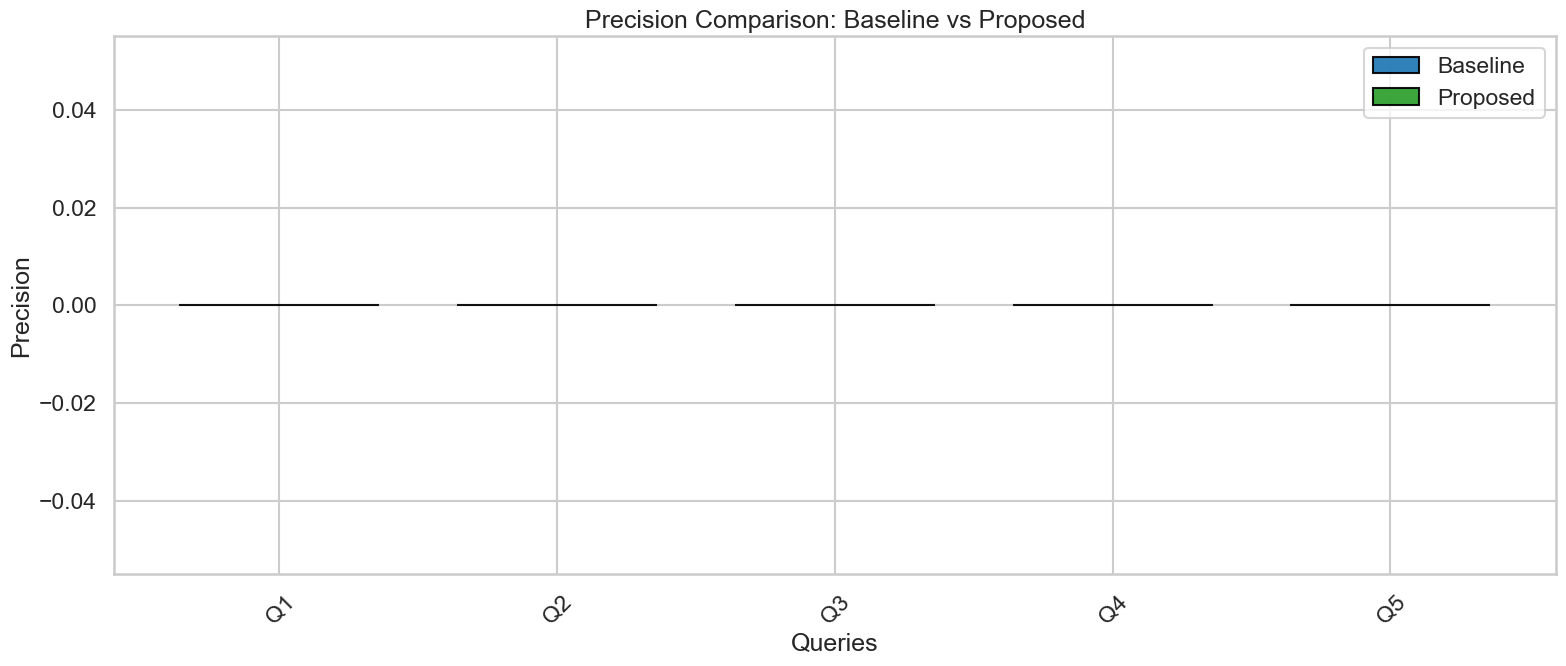

In [68]:
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_Prec"], width=width,
    label="Baseline", color=COLORS["baseline"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_Prec"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Precision")
plt.title("Precision Comparison: Baseline vs Proposed")
plt.legend()
save_show_plot("01_precision_comparison.png")

#### **2. Recall Comparison by Query**

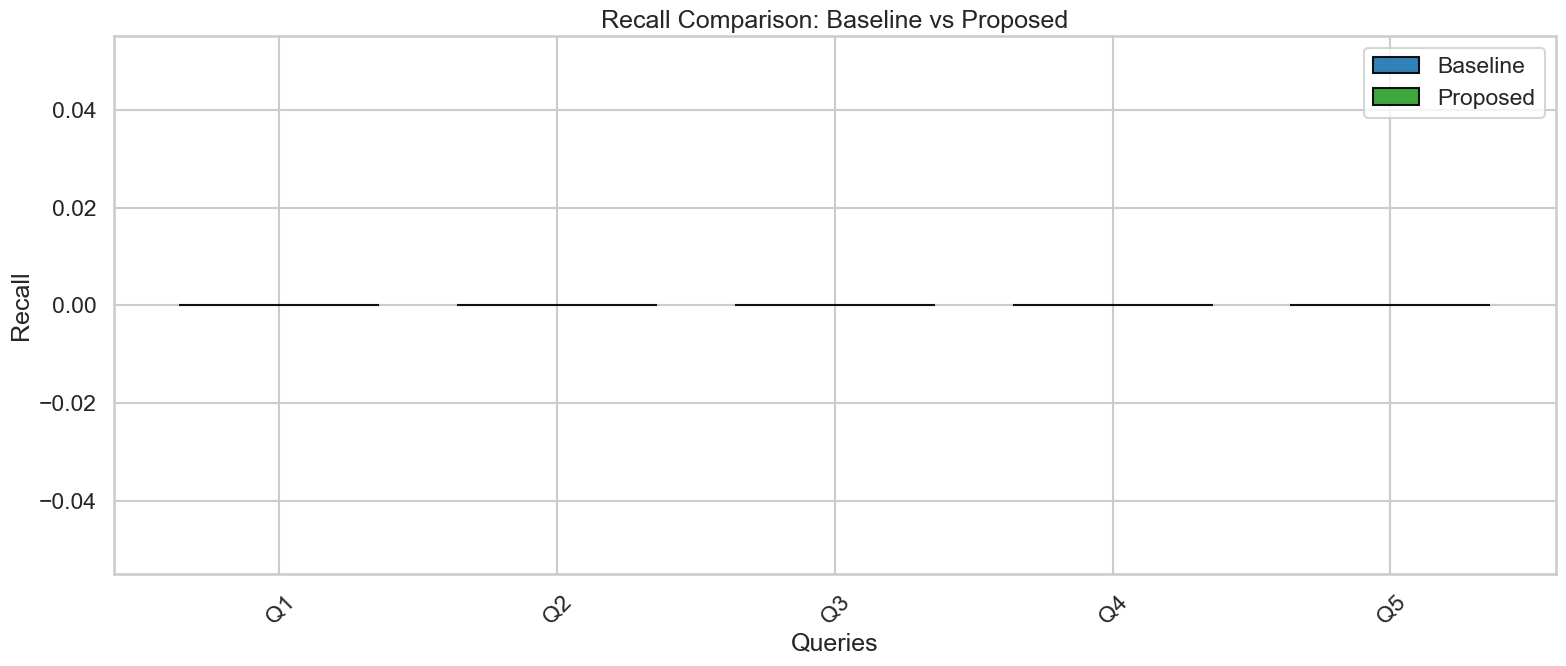

In [69]:
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_Rec"], width=width,
    label="Baseline", color=COLORS["baseline"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_Rec"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Recall")
plt.title("Recall Comparison: Baseline vs Proposed")
plt.legend()
save_show_plot("02_recall_comparison.png")

#### **3. AGS Comparison by Query**

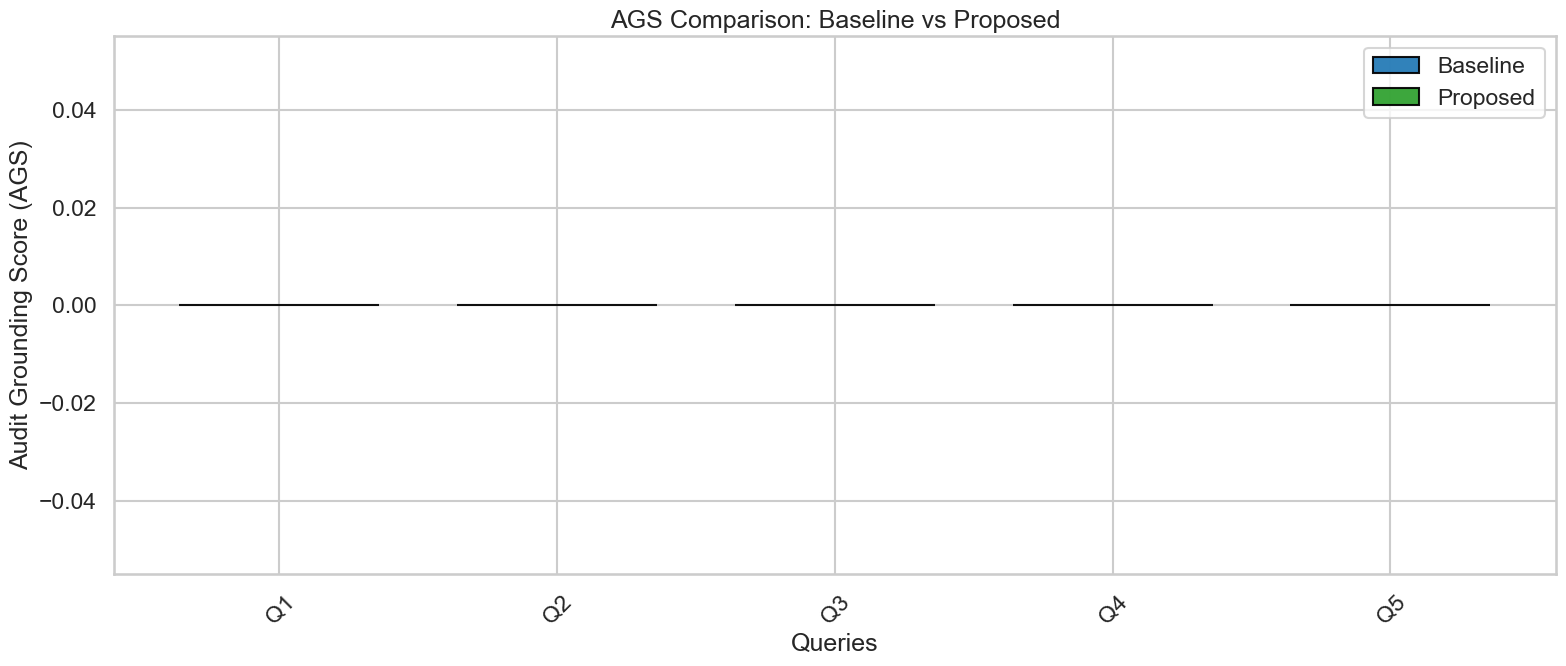

In [70]:
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_AGS"], width=width,
    label="Baseline", color=COLORS["baseline"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_AGS"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Audit Grounding Score (AGS)")
plt.title("AGS Comparison: Baseline vs Proposed")
plt.legend()
save_show_plot("03_ags_comparison.png")

#### **4. Audited / Verified Claim Counts**

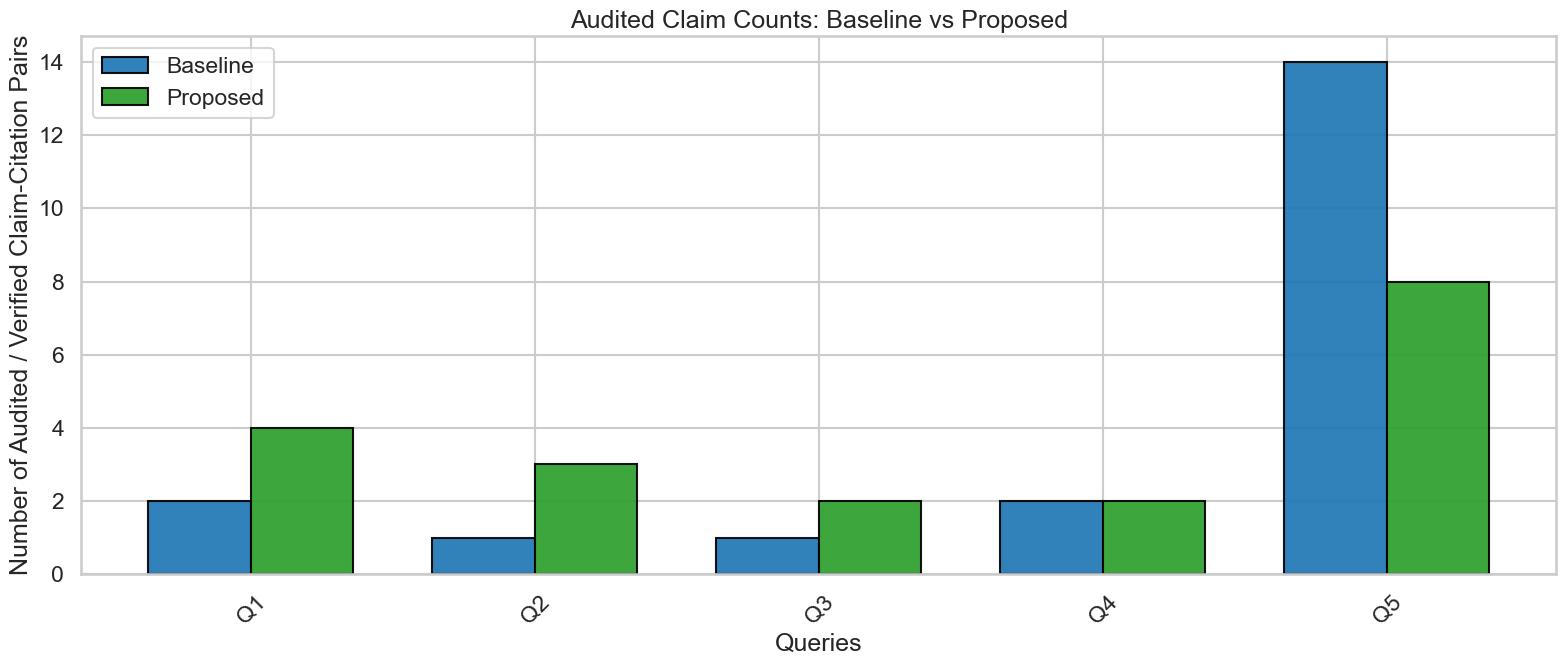

In [71]:
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_Num_Verified_Claims"], width=width,
    label="Baseline", color=COLORS["baseline"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_Num_Verified_Claims"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Number of Audited / Verified Claim-Citation Pairs")
plt.title("Audited Claim Counts: Baseline vs Proposed")
plt.legend()
save_show_plot("04_verified_claim_counts.png")

#### **5. Average Metrics Comparison**

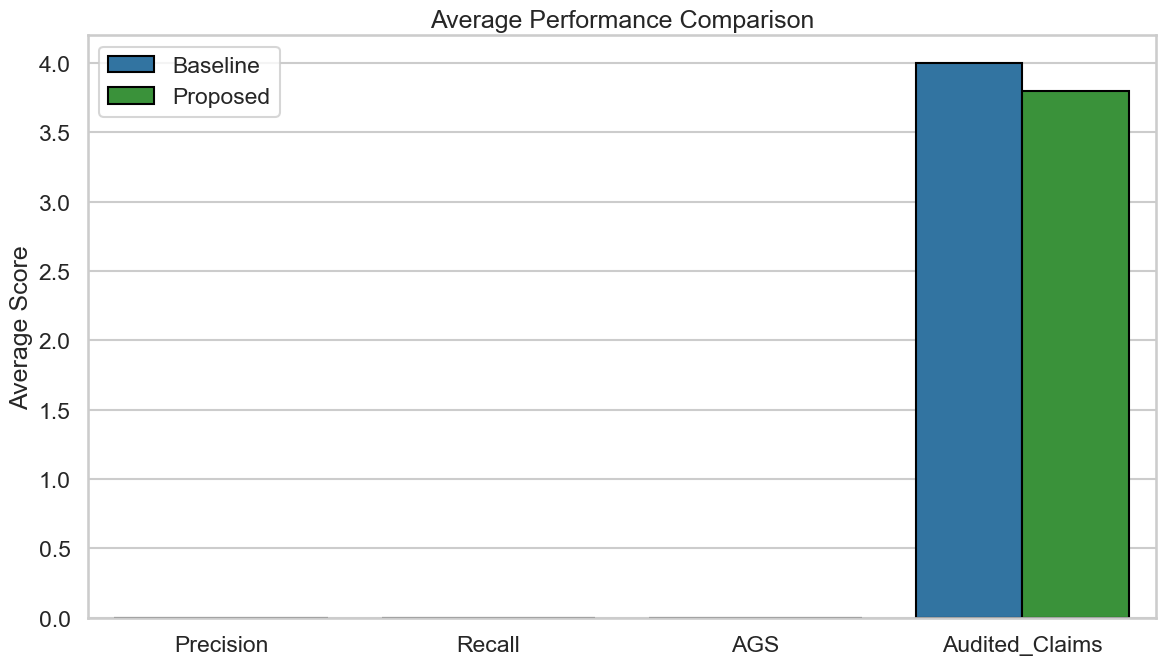

In [72]:
avg_metrics = pd.DataFrame({
    "System": ["Baseline", "Proposed"],
    "Precision": [
        plot_df["Baseline_Prec"].mean(),
        plot_df["Proposed_Prec"].mean()
    ],
    "Recall": [
        plot_df["Baseline_Rec"].mean(),
        plot_df["Proposed_Rec"].mean()
    ],
    "AGS": [
        plot_df["Baseline_AGS"].mean(),
        plot_df["Proposed_AGS"].mean()
    ],
    "Audited_Claims": [
        plot_df["Baseline_Num_Verified_Claims"].mean(),
        plot_df["Proposed_Num_Verified_Claims"].mean()
    ]
})

avg_long = avg_metrics.melt(id_vars="System", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
sns.barplot(
    data=avg_long,
    x="Metric",
    y="Score",
    hue="System",
    palette=[COLORS["baseline"], COLORS["proposed"]],
    edgecolor="black"
)
plt.title("Average Performance Comparison")
plt.ylabel("Average Score")
plt.xlabel("")
plt.legend(title="")
save_show_plot("05_average_metric_comparison.png")

#### **6. Heatmap Overview**

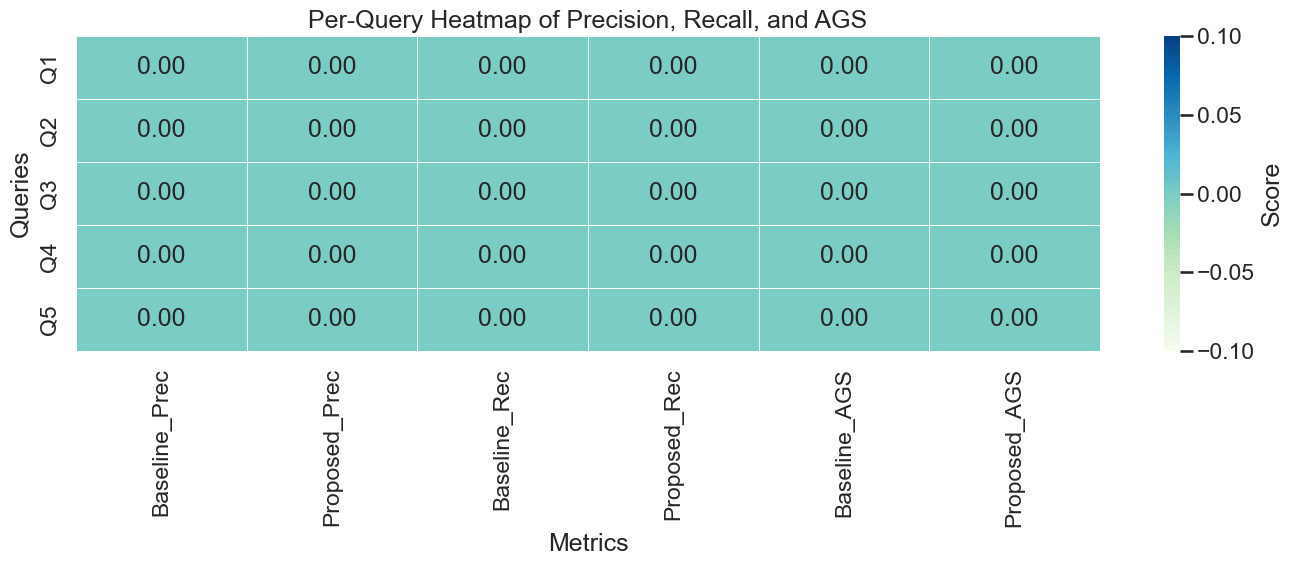

In [73]:
heatmap_cols = [
    "Baseline_Prec", "Proposed_Prec",
    "Baseline_Rec", "Proposed_Rec",
    "Baseline_AGS", "Proposed_AGS"
]

heatmap_df = plot_df.set_index("Query_Label")[heatmap_cols]

plt.figure(figsize=(14, max(6, len(plot_df) * 0.5)))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=COLORS["heatmap"],
    linewidths=0.5,
    cbar_kws={"label": "Score"}
)
plt.title("Per-Query Heatmap of Precision, Recall, and AGS")
plt.xlabel("Metrics")
plt.ylabel("Queries")
save_show_plot("06_two_system_metrics_heatmap.png")

#### **7. Delta: Proposed vs Baseline**

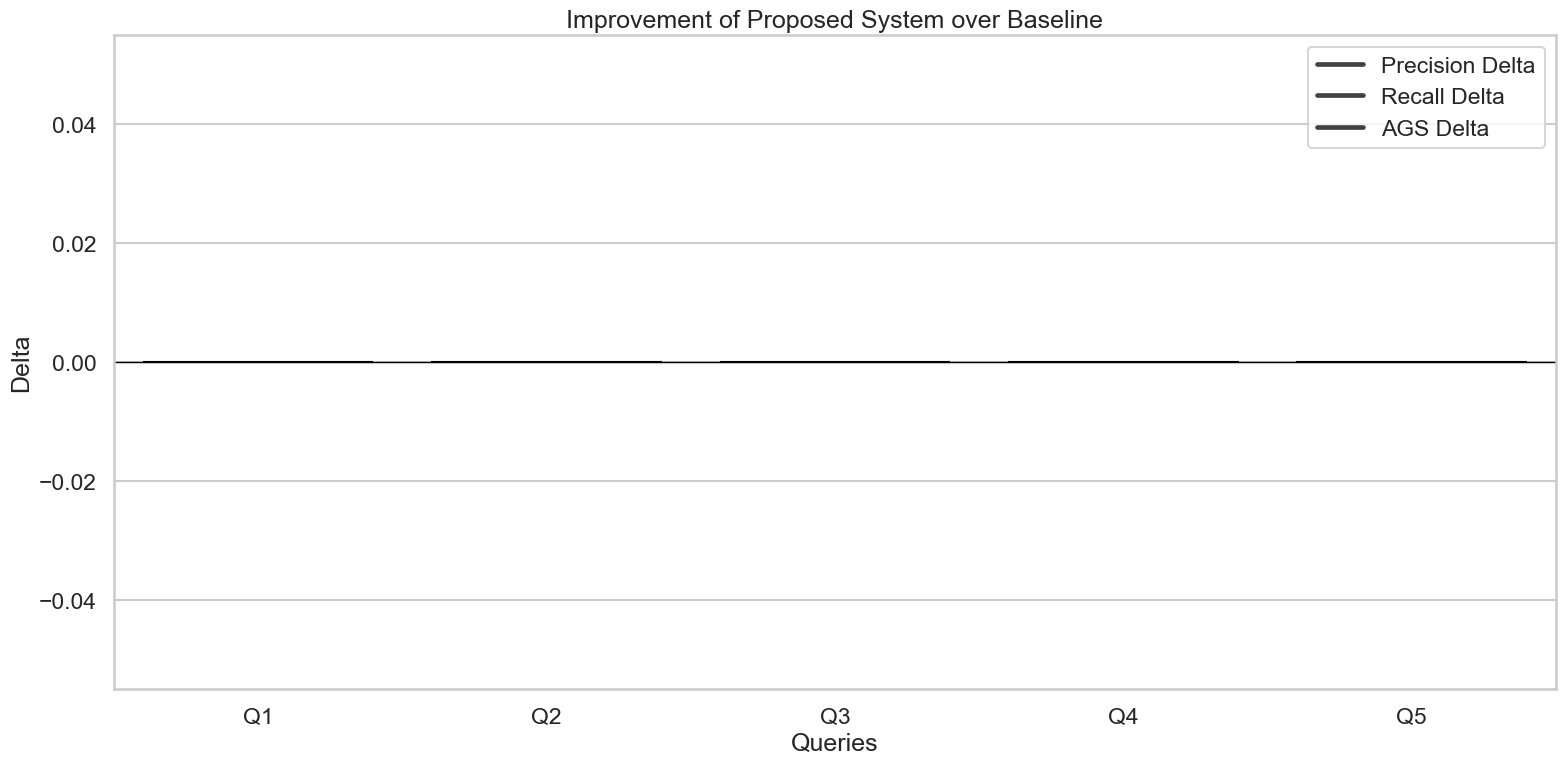

In [74]:
delta_prop_vs_b0 = plot_df[[
    "Query_Label",
    "Delta_Prec_Proposed_vs_Baseline",
    "Delta_Rec_Proposed_vs_Baseline",
    "Delta_AGS_Proposed_vs_Baseline"
]].melt(id_vars="Query_Label", var_name="Metric", value_name="Delta")

metric_palette = {
    "Delta_Prec_Proposed_vs_Baseline": COLORS["delta_prec"],
    "Delta_Rec_Proposed_vs_Baseline": COLORS["delta_rec"],
    "Delta_AGS_Proposed_vs_Baseline": COLORS["delta_ags"]
}

plt.figure(figsize=(16, 8))
sns.barplot(
    data=delta_prop_vs_b0,
    x="Query_Label",
    y="Delta",
    hue="Metric",
    palette=metric_palette,
    edgecolor="black"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Improvement of Proposed System over Baseline")
plt.xlabel("Queries")
plt.ylabel("Delta")
plt.legend(
    title="",
    labels=["Precision Delta", "Recall Delta", "AGS Delta"]
)
save_show_plot("07_delta_proposed_vs_baseline.png")

#### **8. Scatter Plot: Precision vs AGS**

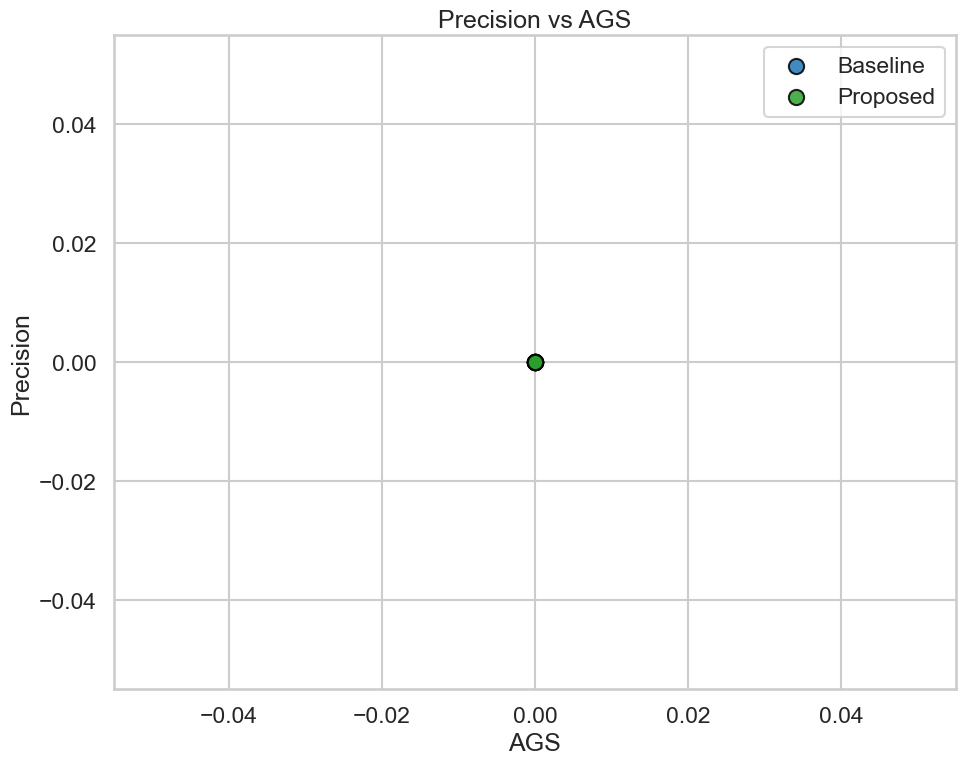

In [75]:
plt.figure(figsize=(10, 8))
plt.scatter(
    plot_df["Baseline_AGS"], plot_df["Baseline_Prec"],
    s=120, color=COLORS["baseline"], label="Baseline",
    alpha=0.85, edgecolors="black"
)
plt.scatter(
    plot_df["Proposed_AGS"], plot_df["Proposed_Prec"],
    s=120, color=COLORS["proposed"], label="Proposed",
    alpha=0.85, edgecolors="black"
)
plt.xlabel("AGS")
plt.ylabel("Precision")
plt.title("Precision vs AGS")
plt.legend()
save_show_plot("08_precision_vs_ags_scatter.png")

#### **9. Scatter Plot: Recall vs AGS**

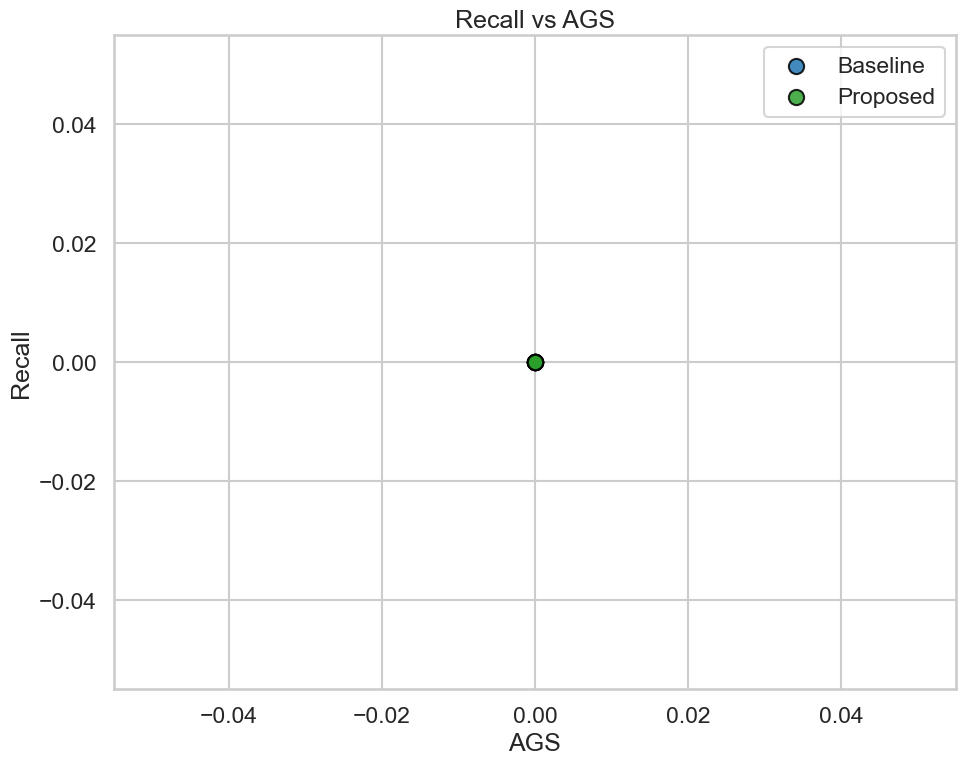

In [76]:
plt.figure(figsize=(10, 8))
plt.scatter(
    plot_df["Baseline_AGS"], plot_df["Baseline_Rec"],
    s=120, color=COLORS["baseline"], label="Baseline",
    alpha=0.85, edgecolors="black"
)
plt.scatter(
    plot_df["Proposed_AGS"], plot_df["Proposed_Rec"],
    s=120, color=COLORS["proposed"], label="Proposed",
    alpha=0.85, edgecolors="black"
)
plt.xlabel("AGS")
plt.ylabel("Recall")
plt.title("Recall vs AGS")
plt.legend()
save_show_plot("09_recall_vs_ags_scatter.png")

#### **10. Pass/Fail Stacked Bars**

In [77]:
if has_pass_fail:
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

    # Baseline
    axes[0].bar(
        plot_df["Query_Label"], plot_df["Baseline_Num_Pass"],
        color=COLORS["pass"], edgecolor="black", label="Pass"
    )
    axes[0].bar(
        plot_df["Query_Label"], plot_df["Baseline_Num_Fail"],
        bottom=plot_df["Baseline_Num_Pass"],
        color=COLORS["fail"], edgecolor="black", label="Fail"
    )
    axes[0].set_title("Baseline")
    axes[0].set_xlabel("Queries")
    axes[0].set_ylabel("Audited Claim-Citation Pairs")
    axes[0].tick_params(axis="x", rotation=45)

    # Proposed
    axes[1].bar(
        plot_df["Query_Label"], plot_df["Proposed_Num_Pass"],
        color=COLORS["pass"], edgecolor="black", label="Pass"
    )
    axes[1].bar(
        plot_df["Query_Label"], plot_df["Proposed_Num_Fail"],
        bottom=plot_df["Proposed_Num_Pass"],
        color=COLORS["fail"], edgecolor="black", label="Fail"
    )
    axes[1].set_title("Proposed")
    axes[1].set_xlabel("Queries")
    axes[1].tick_params(axis="x", rotation=45)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    plt.suptitle("Pass/Fail Distribution", y=1.03)
    plt.tight_layout()
    plt.savefig(
        os.path.join(results_dir, "10_pass_fail_stacked_bars.png"),
        dpi=300, bbox_inches="tight"
    )
    plt.show()
    plt.close()

#### **11. Average Pass/Fail Comparison**

In [81]:
if has_pass_fail:
    avg_pf = pd.DataFrame({
        "System": ["Baseline", "Proposed"],
        "Pass": [
            plot_df["Baseline_Num_Pass"].mean(),
            plot_df["Proposed_Num_Pass"].mean()
        ],
        "Fail": [
            plot_df["Baseline_Num_Fail"].mean(),
            plot_df["Proposed_Num_Fail"].mean()
        ]
    })

    avg_pf_long = avg_pf.melt(
        id_vars="System", var_name="Outcome", value_name="Average_Count"
    )

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=avg_pf_long,
        x="System",
        y="Average_Count",
        hue="Outcome",
        palette={"Pass": COLORS["pass"], "Fail": COLORS["fail"]},
        edgecolor="black"
    )
    plt.title("Average Pass/Fail Counts")
    plt.xlabel("")
    plt.ylabel("Average Count")
    plt.legend(title="")
    save_show_plot("11_average_pass_fail_comparison.png")

#### **12. Line Plot: Precision Trends Across Queries**

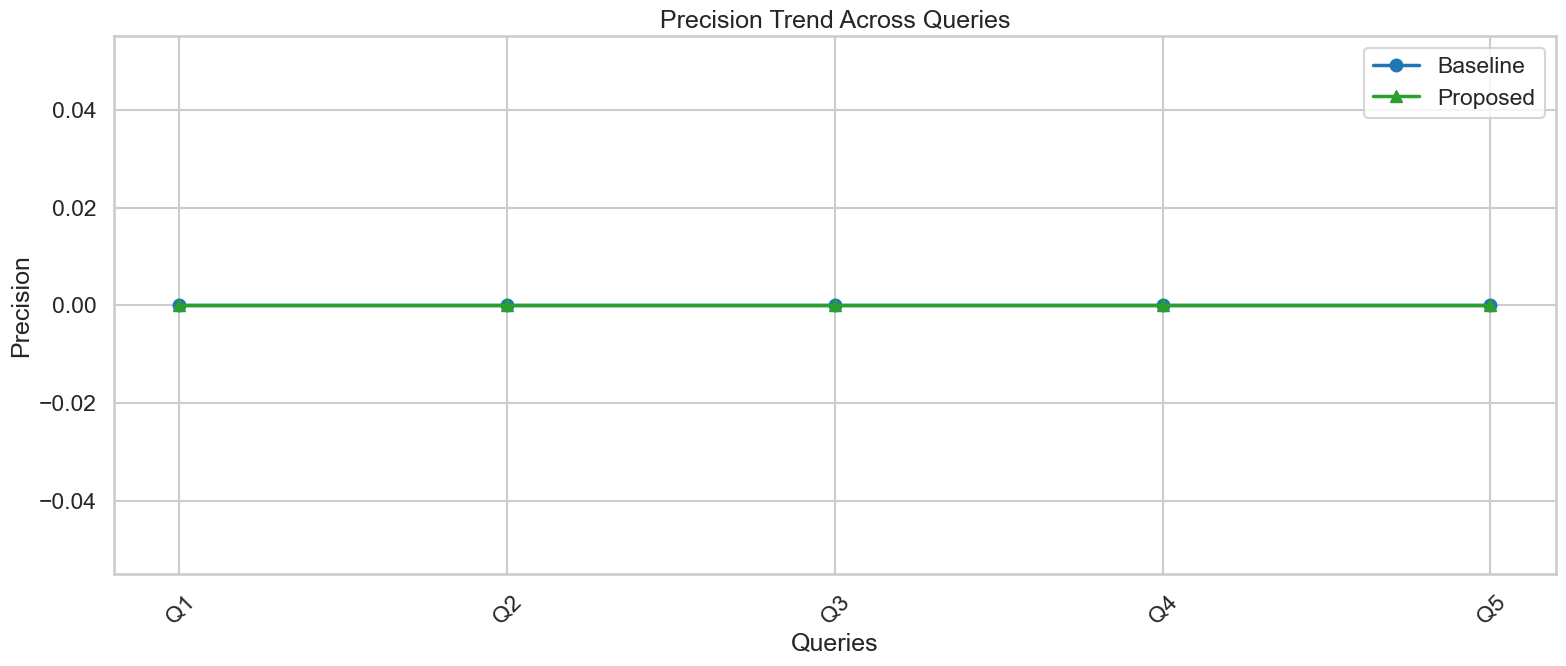

In [79]:
plt.figure(figsize=(16, 7))
plt.plot(
    plot_df["Query_Label"], plot_df["Baseline_Prec"],
    marker="o", linewidth=2.5, label="Baseline",
    color=COLORS["baseline"]
)
plt.plot(
    plot_df["Query_Label"], plot_df["Proposed_Prec"],
    marker="^", linewidth=2.5, label="Proposed",
    color=COLORS["proposed"]
)
plt.xticks(rotation=45)
plt.xlabel("Queries")
plt.ylabel("Precision")
plt.title("Precision Trend Across Queries")
plt.legend()
save_show_plot("12_precision_trend_lines.png")

#### **13. Summary Printout**

In [80]:
print("=== TWO-SYSTEM VISUALISATION SUMMARY ===")
print(f"Average Baseline Precision: {plot_df['Baseline_Prec'].mean():.3f}")
print(f"Average Proposed Precision: {plot_df['Proposed_Prec'].mean():.3f}")
print()
print(f"Average Baseline Recall:    {plot_df['Baseline_Rec'].mean():.3f}")
print(f"Average Proposed Recall:    {plot_df['Proposed_Rec'].mean():.3f}")
print()
print(f"Average Baseline AGS:       {plot_df['Baseline_AGS'].mean():.3f}")
print(f"Average Proposed AGS:       {plot_df['Proposed_AGS'].mean():.3f}")
print()
print(
    "Queries where Proposed > Baseline on Precision: "
    f"{(plot_df['Delta_Prec_Proposed_vs_Baseline'] > 0).sum()} / {len(plot_df)}"
)
print(
    "Queries where Proposed > Baseline on Recall: "
    f"{(plot_df['Delta_Rec_Proposed_vs_Baseline'] > 0).sum()} / {len(plot_df)}"
)
print(
    "Queries where Proposed > Baseline on AGS: "
    f"{(plot_df['Delta_AGS_Proposed_vs_Baseline'] > 0).sum()} / {len(plot_df)}"
)

=== TWO-SYSTEM VISUALISATION SUMMARY ===
Average Baseline Precision: 0.000
Average Proposed Precision: 0.000

Average Baseline Recall:    0.000
Average Proposed Recall:    0.000

Average Baseline AGS:       0.000
Average Proposed AGS:       0.000

Queries where Proposed > Baseline on Precision: 0 / 5
Queries where Proposed > Baseline on Recall: 0 / 5
Queries where Proposed > Baseline on AGS: 0 / 5
